## Generating Mock supernova samples with cosmographi

[Cosmographi](https://github.com/cosmographi/cosmographi) is a framework developed by Connor Stone to simulate Type Ia supernovae and their contaminants, forward model the observational and selection effects, and perform cosmological analysis. 

In order to get a handle on things we can work on with cosmographi, we will start by running a small simulation.

### Initial setup
We are assuming that you have a conda environment that has Python > 3.12. To install cosmography, follow:

```bash
git clone https://github.com/cosmographi/cosmographi.git
cd cosmographi
pip install -e .
```

First things first, we will import various modules and also put some safeguards in place in case the GPU on our machines are heavily in use.

In [3]:
import cosmographi as cp
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from contextlib import closing
import pandas as pd
from time import time
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # pick whichever GPU has more free memory
np.random.seed(0)
key = jax.random.PRNGKey(0)
colours = ["purple", "green", "red", "teal", "brown", "yellow"]

We need to pull 'observations' from the LSST ``` rubin_sim ``` framework. The OpSim simulation framework combines all the various choices for cadence with the instrument and telescope choices, and several computed quantities are provided in a database. The current baseline cadence is presented [here](https://survey-strategy.lsst.io/baseline/index.html). For now we have downloaded the database (this link to the position of the file on Helen should work on your notebook - do not worry about downloading this large database yourself!)


We then pull all the items we need for our simulation from the database. We limit ourselves to 200000 observations from the databse (you can reduce this for rapid testing).

In [4]:
# Extract survey data from the LSST database
# #####################################################################
survey_path = "/home/renee/renee/opsim/baseline_v5.0.1_10yrs.db"
with closing(sqlite3.connect(survey_path)) as conn:
    query = f"""
        SELECT 
            observationId,
            
            observationStartMJD,
            visitExposureTime,
            numExposures,
            airmass,
            fieldRA, 
            fieldDec, 
            rotTelPos, 
            rotSkyPos, 
            skyBrightness,
            band,
            filter,
            seeingFwhmEff,
            observation_reason
        FROM observations
        LIMIT 2000;
        """
    survey_df = pd.read_sql_query(query, conn)
print(survey_df)
assert (
    survey_df["numExposures"].nunique() == 1
), "All exposures should have the same number of exposures."
survey_t = survey_df["observationStartMJD"].values
survey_ra = survey_df["fieldRA"].values
survey_dec = survey_df["fieldDec"].values
survey_exp_time = survey_df["visitExposureTime"].values
survey_airmass = survey_df["airmass"].values
survey_sky_brightness = survey_df["skyBrightness"].values
survey_seeing = survey_df["seeingFwhmEff"].values
survey_PSF_Aeff = 4 * np.pi * (survey_seeing / 2.355) ** 2  # convert FWHM to effective area
survey_band = survey_df["band"].values
survey_obsreason = survey_df["observation_reason"].values

      observationId  observationStartMJD  visitExposureTime  numExposures  \
0                 0         60981.002252               15.0             1   
1                 1         60981.002498               15.0             1   
2                 2         60981.002744               15.0             1   
3                 3         60981.002988               15.0             1   
4                 4         60981.003234               15.0             1   
...             ...                  ...                ...           ...   
1995           1995         60991.338102               30.0             1   
1996           1996         60991.340081               30.0             1   
1997           1997         60991.340527               30.0             1   
1998           1998         60991.340945               30.0             1   
1999           1999         60991.341370               30.0             1   

       airmass     fieldRA   fieldDec  rotTelPos   rotSkyPos  skyBrightness

## Setting up a 'source' to observe
We now need to have a source to observe. In this example we have coded up a Type Ia supernova that is specified by the [SALT2 2021](https://academic.oup.com/mnras/article/504/3/4111/6225808) light curve model, and have assumed Milky Way extinction according to the [Calzetti law](https://iopscience.iop.org/article/10.1086/308692).  We are assuming a standard LCDM cosmology.

(Some of the work this summer will be to include other sources that we can simulate over!)

In [5]:
# Create source
#####################################################################
C = cp.Cosmology()
source_obj = cp.source_factory(cp.SALT2_2021, cp.source.effects.MWExtinction_Calzetti00)
S = source_obj(cosmology=C, A_V_c00mw=0.1, R_V_c00mw=3.1)
S.load_salt2_model()
S.M.to_static()
S.CL.to_static()
print(S)


SALT2_2021_MWExtinction_Calzetti00|SALT2_2021_MWExtinction_Calzetti00
    z|dynamic
    mu|pointer
        Cosmology|Cosmology
            H0|static: 67.9
            Omega_m|static: 0.307
            Omega_k|static: 0
            Omega_r|static: 0
            Omega_l|pointer: 0.693
                Omega_m|static: 0.307
                Omega_k|static: 0
                Omega_r|static: 0
            w0|static: -1
            wa|static: 0
        z|dynamic
    t0|dynamic
    x1|dynamic
    c|dynamic
    M|static: (2, 71, 1441)
    CL|static: [-0.461, 0.754, -0.455, 0.0818]
    A_V_c00mw|static: 0.1
    R_V_c00mw|static: 3.1


You should see from the outout anove what the input parameters in the model are, and that we are not varying the cosmology at this stage (we would do this if we were sampling the cosmological parameters.)

## Setting up the instrument model
We now set up the instrument model. This will change as a function of observations (since the bands we observe and the throughput will differ as a function of our observations), and the throughput is therefor a dynamic variable

In [6]:
#####################################################################
I = cp.RubinObservatory()
I.throughput.trim()
I.throughput.to_dynamic() 
survey_iband = cp.utils.bandstr_to_bandidx(I.throughput.bands, survey_band)
nfilter = len(I.throughput.bands)
print(I)
print(I.get_values().shape)

RubinObservatory|RubinObservatory
    Throughput_wAtmos|Throughput_wAtmos
        air_mass|dynamic: 1.2
    MagAB|MagAB
        Ze|static: (6,)
        Throughput_wAtmos|Throughput_wAtmos
            air_mass|dynamic: 1.2
(1,)


## Generate the SN source sample

Now we can pull our number of supernovae that we want to observe. Here we are 'forcing' the situation where we pick values of right ascension and declination that coincide with the observed point (so we don't waste computational resources). We also restrict our sample to those sources who can be 'observed' 5 times in order to get a good example of the lightcurve.

The default is Nsn = 300 but you can reduce this for testing purposes.

The ```sel_src``` is the list of the selected sources that meet our criteria.

In [ ]:
# Generate mock SN
Nsn = 30 # number of sources that we will simulate
t_range = (np.min(survey_t), np.max(survey_t)) # ranges of times we observe at
source_t = np.random.uniform(*t_range, Nsn) # draw 1 random source times (uniformly dist.)
S.t0 = source_t
R = cp.RateConst(cosmology=C, z_min=0.01, z_max=1.0, r=1)
key, subkey = jax.random.split(key)
source_z = R.sample_z(subkey, source_t.shape)
S.z = source_z
print(source_z)
chooseraddec = np.random.choice(
    len(survey_ra), Nsn
)  # fixme, not right distribution, but good enough for testing
source_ra, source_dec = cp.utils.sample_near(
    survey_ra[chooseraddec], survey_dec[chooseraddec], radius_deg=2, n=Nsn
)
print("Matching sources to survey...")
source_matches = cp.utils.cross_match_survey_circle(
    source_tmin=np.array(jax.vmap(lambda z, t: S.min_time({"z": z, "t0": t}))(source_z, source_t)),
    source_tmax=np.array(jax.vmap(lambda z, t: S.max_time({"z": z, "t0": t}))(source_z, source_t)),
    source_ra=source_ra,
    source_dec=source_dec,
    survey_t=survey_t,
    survey_ra=survey_ra,
    survey_dec=survey_dec,
    survey_fov=3.5,  # degrees, LSST field of view
)
print(f"Matched {len(source_matches)} sources to survey observations.")
for i in list(source_matches.keys()):
    if len(source_matches[i]) < 5:
        del source_matches[
            i
        ]  # drop sources with fewer than 5 matches, not enough data for lightcurve
        continue
print(f"Matched {len(source_matches)} sources worth examining.")
# print(source_matches)
P = cp.source.prior.SALT2_SK16Prior()
x1, c = P.prior_sample(source_t.shape[0])
S.x1 = x1
S.c = c
sel_src = np.sort(list(source_matches.keys()))

print(S)
print(S.get_values().shape)


NameError: name 'np' is not defined

## Build the parameters needed for the light curve fits
We now pull all the relevant information for both the sources and the instrument and link them together - so that for example we know both what the source brightness and the sky brightness are at the same time. 

In [ ]:
# Build params input
#####################################################################
source_values = np.array(S.get_values())
survey_values = np.array(I.get_values())
keys = []
bands = []
exp_times = []
sky_brightnesses = []
PSF_Aeffs = []
obs_t = []
obs_reasons = []
source_params = []
survey_params = []
for i in sel_src:
    _subkeys = jax.random.split(key, len(source_matches[i]) + 1)
    key, subkeys = _subkeys[0], _subkeys[1:]
    keys.append(subkeys)
    bands.append(survey_iband[source_matches[i]])
    exp_times.append(survey_exp_time[source_matches[i]])
    sky_brightnesses.append(survey_sky_brightness[source_matches[i]])
    PSF_Aeffs.append(survey_PSF_Aeff[source_matches[i]])
    obs_t.append(survey_t[source_matches[i]])
    obs_reasons.append(survey_obsreason[source_matches[i]])
    source_params.append(jnp.repeat(source_values[i][None, :], len(source_matches[i]), axis=0))
    survey_params.append(survey_airmass[source_matches[i]][:, None])  # shape (n_obs, 1)
keys = jnp.array(np.concatenate(keys))
bands = jnp.array(np.concatenate(bands))
exp_times = jnp.array(np.concatenate(exp_times))
sky_brightnesses = jnp.array(np.concatenate(sky_brightnesses))
PSF_Aeffs = jnp.array(np.concatenate(PSF_Aeffs))
obs_t = jnp.array(np.concatenate(obs_t))
obs_reasons = np.array(np.concatenate(obs_reasons))
source_params = jnp.array(np.concatenate(source_params, axis=0))
survey_params = jnp.array(np.concatenate(survey_params, axis=0))
print("Keys shape:", keys.shape)
print("Bands shape:", bands.shape)
print("Exp times shape:", exp_times.shape)
print("Source params shape:", source_params.shape)
print("Survey params shape:", survey_params.shape)

Keys shape: (117, 2)
Bands shape: (117,)
Exp times shape: (117,)
Source params shape: (117, 4)
Survey params shape: (117, 1)


## Make lightcurves from observations
We make the light curves from all the observations and use numpy within jax to make the code efficient.

In [9]:
# Run mock survey lightcurves
#####################################################################
vobs = jax.jit(jax.vmap(I.observe, in_axes=(0, 0, 0, 0, 0, None, 0, 0, 0)), static_argnums=(5,))
start = time()
LCs = []
nobs = len(keys)
batch_size = 10000
for i in range(0, nobs, batch_size):
    LCs.append(
        vobs(
            keys[i : i + batch_size],
            bands[i : i + batch_size],
            exp_times[i : i + batch_size],
            sky_brightnesses[i : i + batch_size],
            PSF_Aeffs[i : i + batch_size],
            S,
            obs_t[i : i + batch_size],
            source_params[i : i + batch_size],
            survey_params[i : i + batch_size],
        )
    )
LCs = tuple(
    jnp.concatenate(tuple(LCs[i][f] for i in range(len(LCs))), axis=0) for f in range(len(LCs[0]))
)
print(LCs[0].block_until_ready().shape)
print(f"Generated lightcurves in {time() - start:.2f} seconds.")
print("LCs shape:", list(lc.shape for lc in LCs))

(117,)
Generated lightcurves in 1.34 seconds.
LCs shape: [(117,), (117,), (117,), (117,)]


## Make a plot for one source
We pull off one observation and plot the errors on our observations for one selected source (here s``` eli = 19```)

(true - obs) / err: [-1.27299231 -2.30895457  0.47323644 -0.44773244 -0.92108291  0.43092789]


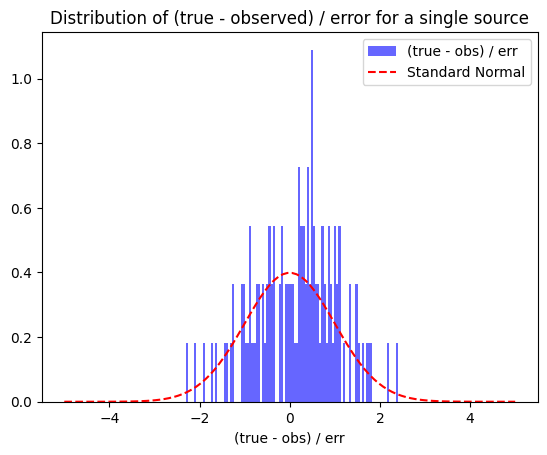

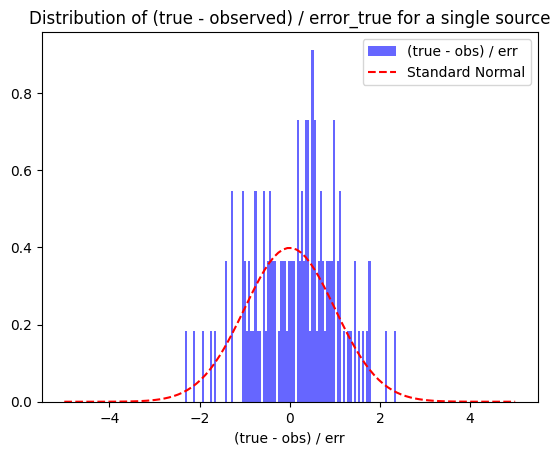

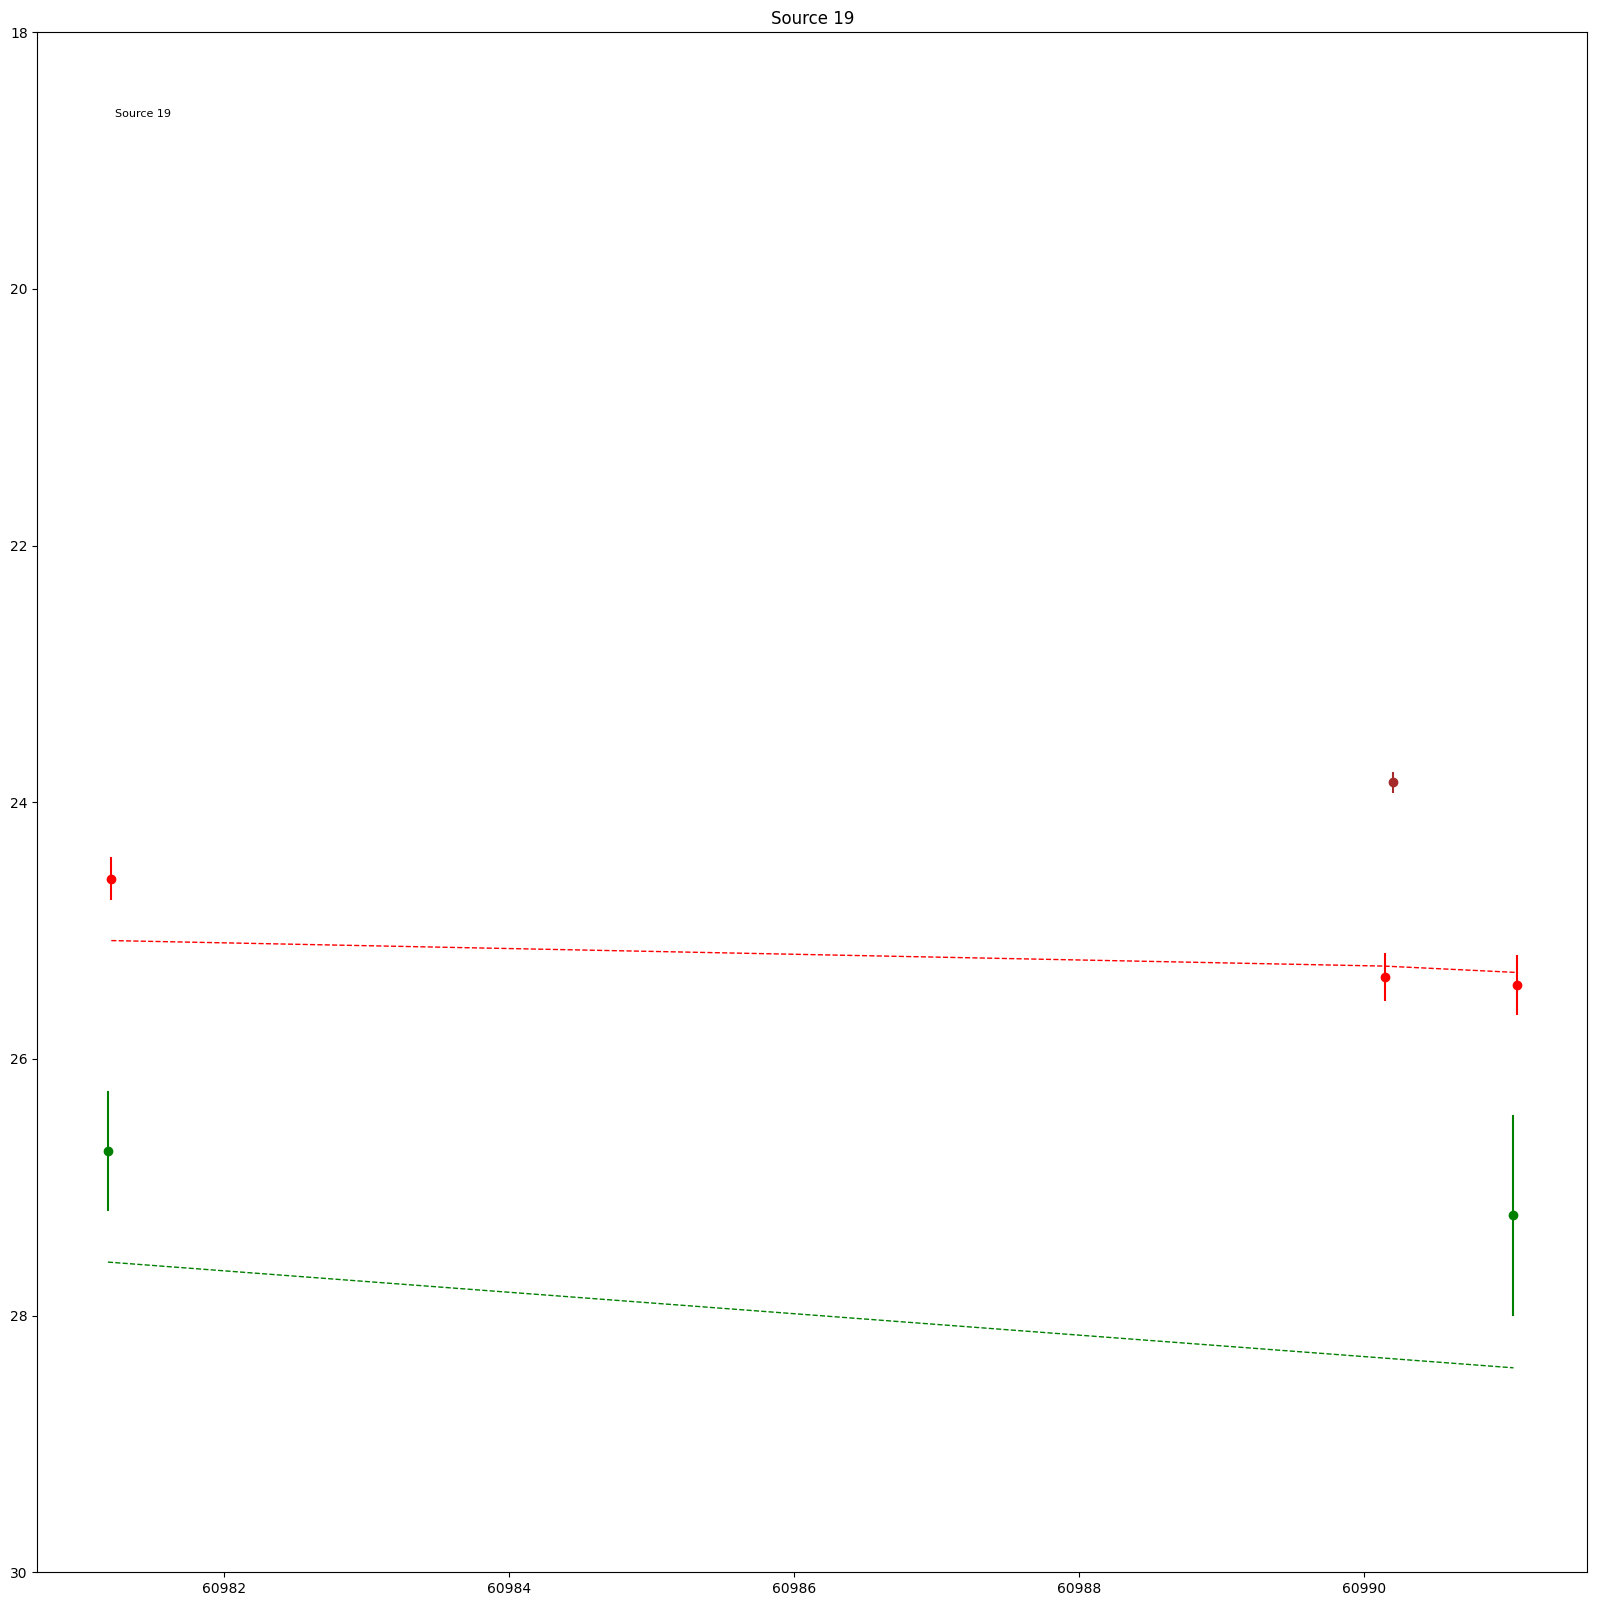

In [10]:
# Plot results single source
####################################################################
seli = 19
spot = sum(len(source_matches[i]) for i in sel_src if i < seli)
ibands = bands[spot : spot + len(source_matches[seli])]
lc_obs = LCs[0][spot : spot + len(source_matches[seli])]
lc_err = LCs[1][spot : spot + len(source_matches[seli])]
lc_err_mag = jnp.abs(
    jax.vmap(I.mag_system.err)(
        lc_obs, lc_err, survey_airmass[spot : spot + len(source_matches[seli])][:, None]
    )
)
lc_obs_mag = jax.vmap(I.mag_system.flux_to_mag)(
    ibands, lc_obs, survey_airmass[spot : spot + len(source_matches[seli])][:, None]
)
lc_true = LCs[2][spot : spot + len(source_matches[seli])]
lc_true_mag = jax.vmap(I.mag_system.flux_to_mag)(
    ibands, lc_true, survey_airmass[spot : spot + len(source_matches[seli])][:, None]
)
lc_err_true = LCs[3][spot : spot + len(source_matches[seli])]
print("(true - obs) / err:", (lc_true - lc_obs) / lc_err)
plt.hist(
    (LCs[2] - LCs[0]) / LCs[1],
    bins=100,
    density=True,
    alpha=0.6,
    color="b",
    label="(true - obs) / err",
)
plt.plot(
    jnp.linspace(-5, 5, 100),
    jax.scipy.stats.norm.pdf(jnp.linspace(-5, 5, 100)),
    color="r",
    linestyle="--",
    label="Standard Normal",
)
plt.xlabel("(true - obs) / err")
plt.title("Distribution of (true - observed) / error for a single source")
plt.legend()
plt.savefig(f"mock_lightcurve_residuals_source_{seli}.pdf", bbox_inches="tight")
plt.show()
plt.hist(
    (LCs[2] - LCs[0]) / LCs[3],
    bins=100,
    density=True,
    alpha=0.6,
    color="b",
    label="(true - obs) / err",
)
plt.plot(
    jnp.linspace(-5, 5, 100),
    jax.scipy.stats.norm.pdf(jnp.linspace(-5, 5, 100)),
    color="r",
    linestyle="--",
    label="Standard Normal",
)
plt.xlabel("(true - obs) / err")
plt.title("Distribution of (true - observed) / error_true for a single source")
plt.legend()
plt.savefig(f"mock_lightcurve_true_residuals_source_{seli}.pdf", bbox_inches="tight")
plt.show()
fig, ax = plt.subplots(figsize=(20, 20))
for iband in np.unique(ibands):
    sel_band = ibands == iband
    ax.errorbar(
        obs_t[spot : spot + len(source_matches[seli])][sel_band],
        lc_obs_mag[sel_band],
        yerr=lc_err_mag[sel_band],
        fmt="o",
        label=f"Observed {I.throughput.bands[iband]}",
        color=colours[iband],
    )
    ax.plot(
        obs_t[spot : spot + len(source_matches[seli])][sel_band],
        lc_true_mag[sel_band],
        color=colours[iband],
        linestyle="--",
        linewidth=1,
        label="True",
    )
ax.errorbar(
    obs_t[spot : spot + len(source_matches[seli])],
    lc_obs,
    yerr=lc_err,
    color="r",
    fmt="o",
    label="Observed",
)
ax.set_title(f"Source {seli}")
ax.text(0.05, 0.95, f"Source {seli}", transform=ax.transAxes, fontsize=8, verticalalignment="top")
ax.set_ylim(18, 30)
ax.invert_yaxis()
# ax.set_xticks([])
# ax.set_yticks([])
spot += len(source_matches[seli])
plt.savefig(f"mock_lightcurve_source_{seli}.pdf", bbox_inches="tight")
plt.show()

## Now we plot the results for a range of light curves
We make a plot of many different light curves.

{1: array([ 185,  509,  557,  796,  821, 1043, 1052, 1183, 1184, 1641, 1642,
       1696, 1697]), 2: array([ 102,  104,  154,  156,  463,  465, 1421, 1483]), 6: array([ 207,  518,  566,  777,  802, 1048, 1202]), 7: array([  76,  128,  437, 1368, 1430]), 8: array([ 111,  163,  472, 1368, 1430]), 11: array([ 343,  395, 1232, 1506, 1531, 1617, 1672, 1921, 1973]), 13: array([  68,  120,  429, 1379, 1380, 1441, 1442, 1488, 1513]), 16: array([ 178,  485,  533,  790,  815, 1067, 1208, 1598, 1653]), 17: array([ 362,  414, 1222, 1623, 1678, 1914, 1966]), 18: array([ 187,  510,  558,  796,  821, 1043, 1184, 1641, 1696, 1703, 1753]), 19: array([ 330,  382, 1066, 1198, 1631, 1686]), 20: array([  85,  137,  446, 1404, 1466]), 21: array([ 495,  543, 1100, 1302, 1354]), 22: array([ 834,  888, 1550, 1551, 1576, 1577]), 25: array([ 374,  426, 1089, 1093, 1166, 1169, 1809]), 28: array([1094, 1165, 1818, 1905, 1957])}
[ 1  2  6  7  8 11 13 16 17 18 19 20 21 22 25 28]


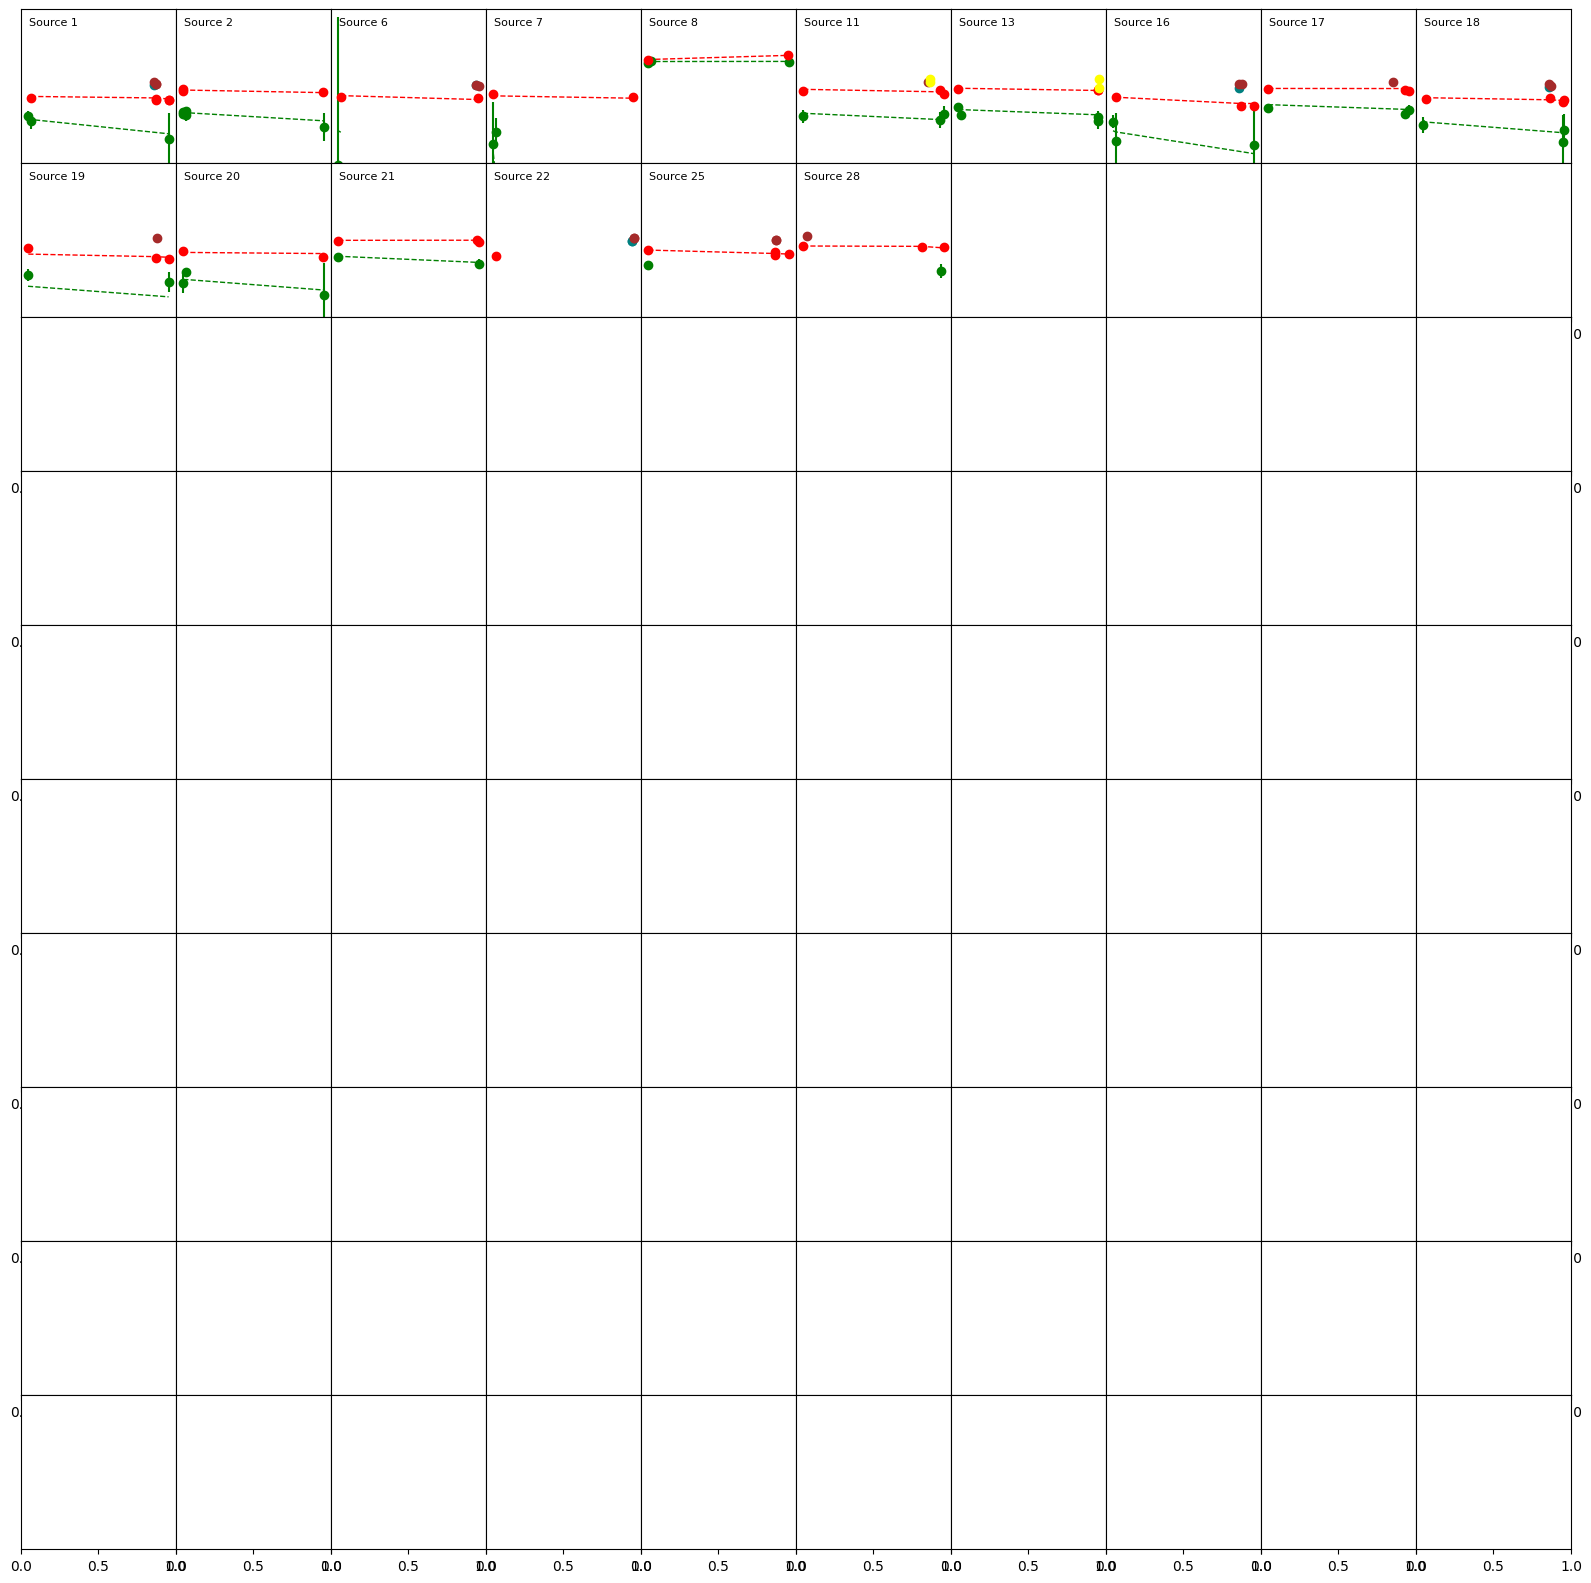

In [11]:
# Plot results
#####################################################################
fig, axarr = plt.subplots(10, 10, figsize=(20, 20), sharey=True)
plt.subplots_adjust(hspace=0, wspace=0)
spot = 0

print (source_matches)
print(sel_src[:100])


for i, ax in zip(sel_src[:100], axarr.flatten()):
    ibands = bands[spot : spot + len(source_matches[i])]
    lc_obs = LCs[0][spot : spot + len(source_matches[i])]
    lc_err = LCs[1][spot : spot + len(source_matches[i])]
    lc_err_mag = jnp.abs(
        jax.vmap(I.mag_system.err)(
            lc_obs, lc_err, survey_airmass[spot : spot + len(source_matches[i])][:, None]
        )
    )
    lc_obs_mag = jax.vmap(I.mag_system.flux_to_mag)(
        ibands, lc_obs, survey_airmass[spot : spot + len(source_matches[i])][:, None]
    )
    lc_true = LCs[2][spot : spot + len(source_matches[i])]
    lc_true_mag = jax.vmap(I.mag_system.flux_to_mag)(
        ibands, lc_true, survey_airmass[spot : spot + len(source_matches[i])][:, None]
    )
    # lc_err_true = LCs[3][spot : spot + len(source_matches[i])]
    for iband in np.unique(ibands):
        sel_band = ibands == iband
        ax.errorbar(
            obs_t[spot : spot + len(source_matches[i])][sel_band],
            lc_obs_mag[sel_band],
            yerr=lc_err_mag[sel_band],
            fmt="o",
            label=f"Observed {I.throughput.bands[iband]}",
            color=colours[iband],
        )
        ax.plot(
            obs_t[spot : spot + len(source_matches[i])][sel_band],
            lc_true_mag[sel_band],
            color=colours[iband],
            linestyle="--",
            linewidth=1,
            label="True",
        )

    ax.text(0.05, 0.95, f"Source {i}", transform=ax.transAxes, fontsize=8, verticalalignment="top")
    ax.set_ylim(18, 30)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    spot += len(source_matches[i])
plt.savefig("mock_lightcurves.pdf", bbox_inches="tight")
plt.show()
